In [ ]:
# Khai báo thư viện
import pandas as pd
import numpy as np

# Đọc dữ liệu
df = pd.read_csv("Diabetes.csv")

# Hiển thị thông tin ban đầu về dữ liệu
print("Thông tin dữ liệu ban đầu:")
print(df.info())
print("\nSố lượng giá trị 0 trong mỗi cột:")
print((df == 0).sum())

columns_to_process = [col for col in df.columns if col not in ['Pregnancies', 'Outcome']]
for col in columns_to_process:
    if df[col].dtype in ['float64', 'int64']:
        median = df[col][df[col] != 0].median()  # Tính trung vị bỏ qua giá trị 0
        df[col] = df[col].apply(lambda x: median if x == 0 else x)  # Thay thế 0 bằng trung vị

# Lưu dữ liệu đã tiền xử lý vào file mới
processed_file_path = 'Diabetes_processed.csv'
df.to_csv(processed_file_path, index=False)
print(f"Dữ liệu đã được lưu vào: {processed_file_path}")


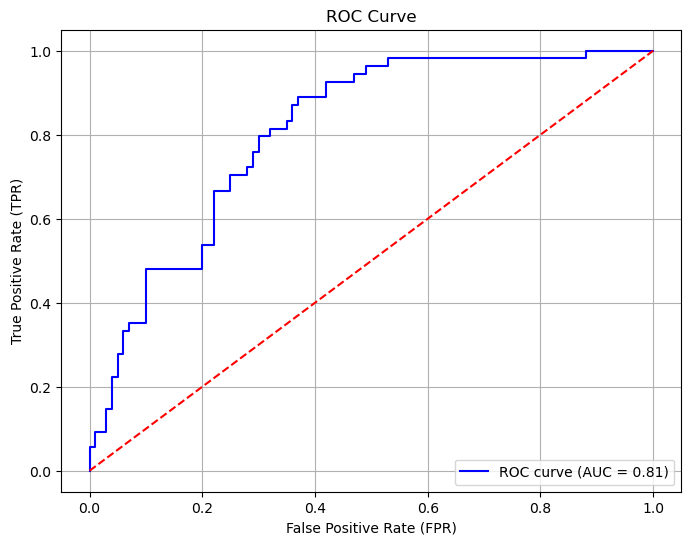

In [6]:
# Khai báo thư viện
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Đọc và chuẩn hóa dữ liệu
df = pd.read_csv("Diabetes_processed.csv")
X = MinMaxScaler().fit_transform(df.drop("Outcome", axis=1))
y = df["Outcome"]

# Chia dữ liệu thành tập huấn luyện và kiểm tra (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Huấn luyện mô hình và dự đoán xác suất
model = LogisticRegression(max_iter=200).fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]

# Tính FPR, TPR và AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# Vẽ biểu đồ ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.2f})", color="blue")
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()
